In [1]:
import pandas as pd 







In [4]:
data.shape

(8469, 17)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
# Set aesthetic style for plots
sns.set_theme(style="whitegrid")

In [3]:
df=pd.read_csv(r"C:\Users\SRINATH\Desktop\data science\machine learing\ml project\data\raw\customer_support_tickets.csv",sep=',')

In [15]:
# Display the first few rows
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text_len
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,284
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,282
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,275
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,262
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,333


# data quality 

In [4]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [16]:
print("--- Data Info ---")
display(df.info())
print("\n--- Missing Values Analysis ---")
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
quality_df = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_pct})
# Show columns that have missing values
display(quality_df[quality_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null 

None


--- Missing Values Analysis ---


,Missing Count,Percentage (%)
Resolution,5700,67.304286
Time to Resolution,5700,67.304286
Customer Satisfaction Rating,5700,67.304286
First Response Time,2819,33.286102


# Summary Statistics
#Understand the range, mean, and distribution of your numerica#l and categorical data.

In [17]:
print("--- Numerical Data Summary ---")
display(df.describe())
print("\n--- Categorical Data Summary ---")
display(df.describe(include=['object']))

--- Numerical Data Summary ---


,Ticket ID,Customer Age,Customer Satisfaction Rating,text_len
count,8469.000000,8469.000000,2769.000000,8469.000000
mean,4235.000000,44.026804,2.991333,289.821939
std,2444.934048,15.296112,1.407016,43.593954
min,1.000000,18.000000,1.000000,151.000000
25%,2118.000000,31.000000,2.000000,273.000000
50%,4235.000000,44.000000,3.000000,298.000000
75%,6352.000000,57.000000,4.000000,318.000000
max,8469.000000,70.000000,5.000000,397.000000



--- Categorical Data Summary ---


,Customer Name,Customer Email,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
count,8469,8469,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769
unique,8028,8320,3,42,730,5,16,8077,3,2769,4,4,5470,2728
top,Michael Garcia,asmith@example.com,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 15:21:42,2023-06-01 17:14:42
freq,5,4,2896,240,24,1752,576,25,2881,1,2192,2143,3,3


<!-- summary statistics -->

# Target Label Distribution (Ticket Priority)

In ticket classification, we need to see if the classes are balanced.

C:\Users\SRINATH\AppData\Local\Temp\ipykernel_31240\3603637844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="viridis", order=df[target_col].value_counts().index)


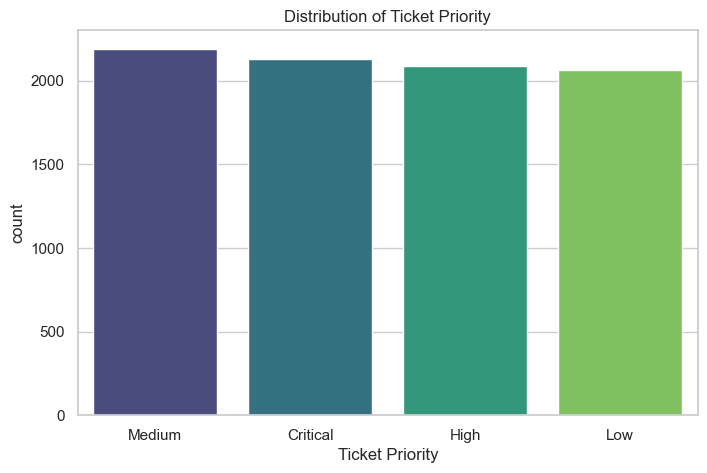

Value Counts for Ticket Priority:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [18]:
# Assuming 'Ticket Priority' is a key column. Change name if different in your CSV.
target_col = 'Ticket Priority' 
if target_col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=target_col, palette="viridis", order=df[target_col].value_counts().index)
    plt.title(f"Distribution of {target_col}")
    plt.show()
    
    print(f"Value Counts for {target_col}:")
    print(df[target_col].value_counts())

# Time-Series Quality Check
Checking if the tickets were logged correctly over time (if date columns exist).

Successfully converted Date of Purchase to datetime.
Successfully converted First Response Time to datetime.
Successfully converted Time to Resolution to datetime.


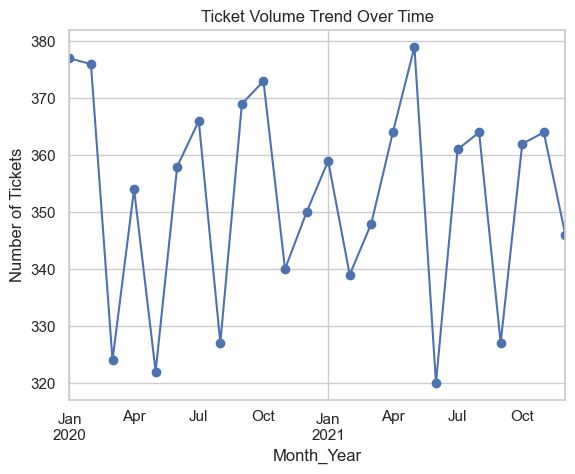

In [19]:
# Try to find date columns automatically
date_cols = [col for col in df.columns if 'Date' in col or 'Time' in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Successfully converted {col} to datetime.")
if date_cols:
    df['Month_Year'] = df[date_cols[0]].dt.to_period('M')
    df.groupby('Month_Year').size().plot(kind='line', marker='o')
    plt.title("Ticket Volume Trend Over Time")
    plt.ylabel("Number of Tickets")
    plt.show()

# Ticket Subject/Body Length Analysis
nce this is an ML project for classification, the length of the text is a huge feature.

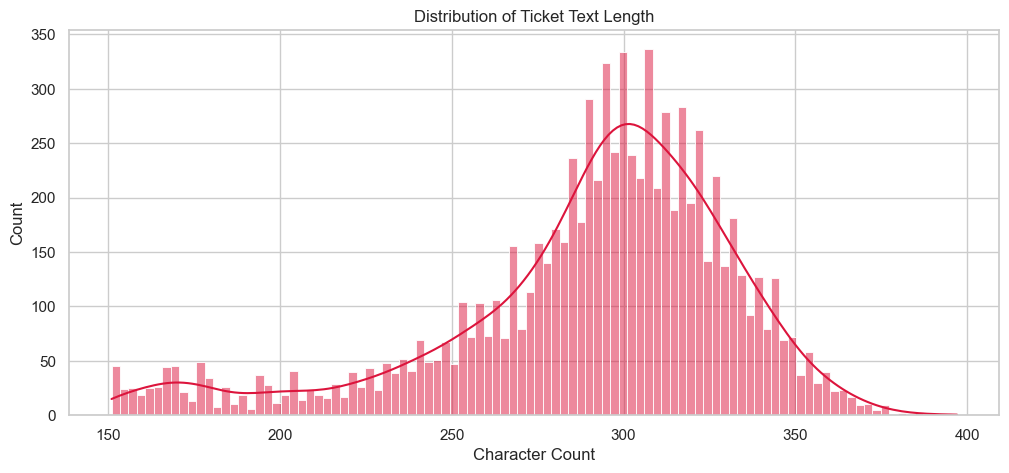

Average text length: 289.82
Longest text: 397


In [20]:
# Column for the actual ticket message
text_col = 'Ticket Description' 
if text_col in df.columns:
    df['text_len'] = df[text_col].astype(str).apply(len)
    
    plt.figure(figsize=(12, 5))
    sns.histplot(df['text_len'], bins=100, color='crimson', kde=True)
    plt.title("Distribution of Ticket Text Length")
    plt.xlabel("Character Count")
    plt.show()
    
    print(f"Average text length: {df['text_len'].mean():.2f}")
    print(f"Longest text: {df['text_len'].max()}")

#  Relationship Between Priority and Resolution Time

In [21]:
# Assuming 'Time to Resolution' exists
res_col = 'Resolution Time' # Update based on your columns
if res_col in df.columns and target_col in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=target_col, y=res_col)
    plt.title(f"Impact of {target_col} on {res_col}")
    plt.show()

In [22]:
print("--- Data Quality: Column Health ---")
# Check for missing values
quality = pd.DataFrame({
    'Columns': df.columns,
    'Non-Null Count': df.count().values,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df)) * 100
})
# Highlight high-missing columns (> 50% missing)
display(quality[quality['Missing Count'] > 0].sort_values(by='Missing %', ascending=False))
# Date Conversion
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
print("\n✅ Converted 'Date of Purchase' to datetime.")

--- Data Quality: Column Health ---


,Columns,Non-Null Count,Missing Count,Missing %
11,Resolution,2769,5700,67.304286
15,Time to Resolution,2769,5700,67.304286
16,Customer Satisfaction Rating,2769,5700,67.304286
14,First Response Time,5650,2819,33.286102



✅ Converted 'Date of Purchase' to datetime.


NameError: name 'viz_df' is not defined

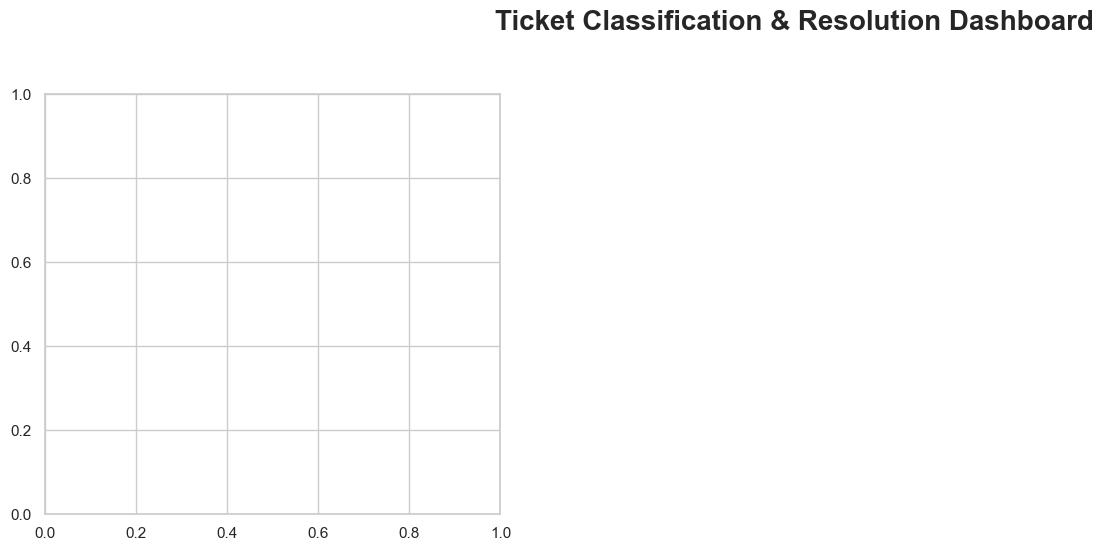

In [23]:
import matplotlib.gridspec as gridspec
# Create a figure with a custom layout
plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3)
plt.suptitle('Ticket Classification & Resolution Dashboard', fontsize=20, fontweight='bold', y=0.95)
# 1. TEAM DISTRIBUTION (Pie Chart)
ax1 = plt.subplot(gs[0, 0])
viz_df['team'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, explode=[0.05]*viz_df['team'].nunique(), shadow=True, cmap='Pastel1')
ax1.set_title('Target Teams', fontweight='bold')
ax1.set_ylabel('')
# 2. PRIORITY DISTRIBUTION (Bar Chart)
ax2 = plt.subplot(gs[0, 1])
p_order = ['Low', 'Medium', 'High', 'Critical']
sns.countplot(data=viz_df, x='priority', order=[o for o in p_order if o in viz_df['priority'].unique()], ax=ax2, palette='coolwarm')
ax2.set_title('Ticket Priority Levels', fontweight='bold')
# 3. TYPE DISTRIBUTION (Horizontal Bar)
ax3 = plt.subplot(gs[0, 2])
sns.countplot(data=viz_df, y='type', ax=ax3, palette='viridis', order=viz_df['type'].value_counts().index)
ax3.set_title('Incident Types', fontweight='bold')
# 4. ACTION STATUS (Donut Chart)
ax4 = plt.subplot(gs[1, 0])
action_counts = viz_df['action'].value_counts()
plt.pie(action_counts, labels=action_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'), pctdistance=0.85)
center_circle = plt.Circle((0,0), 0.70, fc='white')
ax4.add_artist(center_circle)
ax4.set_title('Action/Status Distribution', fontweight='bold')
# 5. TTR HOURS DISTRIBUTION (Histogram)
ax5 = plt.subplot(gs[1, 1:])
sns.histplot(viz_df['ttr'].dropna(), bins=30, kde=True, color='purple', ax=ax5)
ax5.set_title('Time to Resolve (TTR Hours) Distribution', fontweight='bold')
ax5.set_xlabel('Hours')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [24]:
# Create a heatmap of average TTR by Team and Priority
plt.figure(figsize=(12, 6))
pivot_ttr = viz_df.pivot_table(values='ttr', index='team', columns='priority', aggfunc='mean')
sns.heatmap(pivot_ttr, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Avg TTR (Hours)'})
plt.title('Heatmap: Average Resolution Time (Hours) by Team & Priority')
plt.show()

NameError: name 'viz_df' is not defined

<Figure size 1200x600 with 0 Axes>

C:\Users\SRINATH\AppData\Local\Temp\ipykernel_31240\1526770000.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Type', ax=axes[0], palette='viridis')
C:\Users\SRINATH\AppData\Local\Temp\ipykernel_31240\1526770000.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Priority', ax=axes[1], palette='magma',
C:\Users\SRINATH\AppData\Local\Temp\ipykernel_31240\1526770000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Channel', ax=axes[2], palette='Set2')


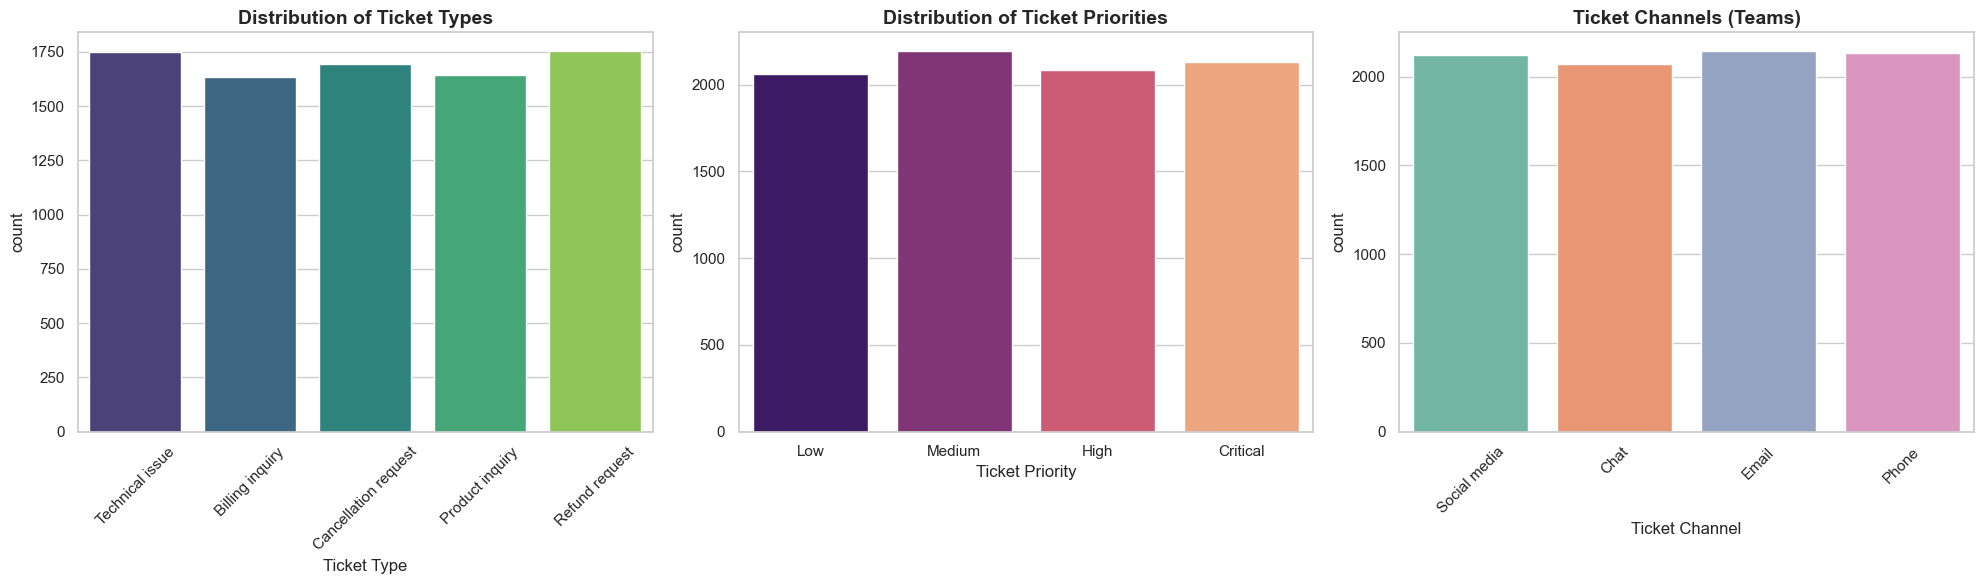

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# 1. Ticket Type Distribution (Project Objective)
sns.countplot(data=df, x='Ticket Type', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Ticket Types', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
# 2. Ticket Priority Distribution (Model Objective)
sns.countplot(data=df, x='Ticket Priority', ax=axes[1], palette='magma', 
              order=['Low', 'Medium', 'High', 'Critical'])
axes[1].set_title('Distribution of Ticket Priorities', fontsize=14, fontweight='bold')
# 3. Ticket Channel / Team (Proxy for "Team" Prediction)
sns.countplot(data=df, x='Ticket Channel', ax=axes[2], palette='Set2')
axes[2].set_title('Ticket Channels (Teams)', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\SRINATH\AppData\Local\Temp\ipykernel_31240\838737130.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['ttr_numeric'] = pd.to_numeric(df['Time to Resolution'].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')


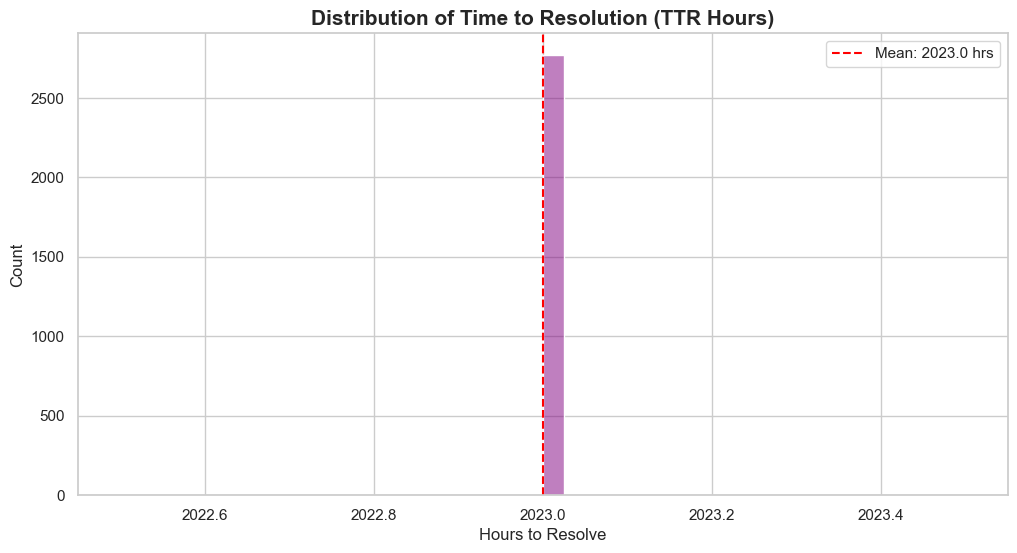

Total entries for TTR training: 2769


In [26]:
# Cleaning the 'Time to Resolution' column for visualization
# It's an object, so we convert it to numeric (removing text if present)
df['ttr_numeric'] = pd.to_numeric(df['Time to Resolution'].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')
plt.figure(figsize=(12, 6))
sns.histplot(df['ttr_numeric'].dropna(), bins=40, kde=True, color='purple')
plt.axvline(df['ttr_numeric'].mean(), color='red', linestyle='--', label=f'Mean: {df["ttr_numeric"].mean():.1f} hrs')
plt.title('Distribution of Time to Resolution (TTR Hours)', fontsize=15, fontweight='bold')
plt.xlabel('Hours to Resolve')
plt.legend()
plt.show()
print(f"Total entries for TTR training: {df['ttr_numeric'].notnull().sum()}")

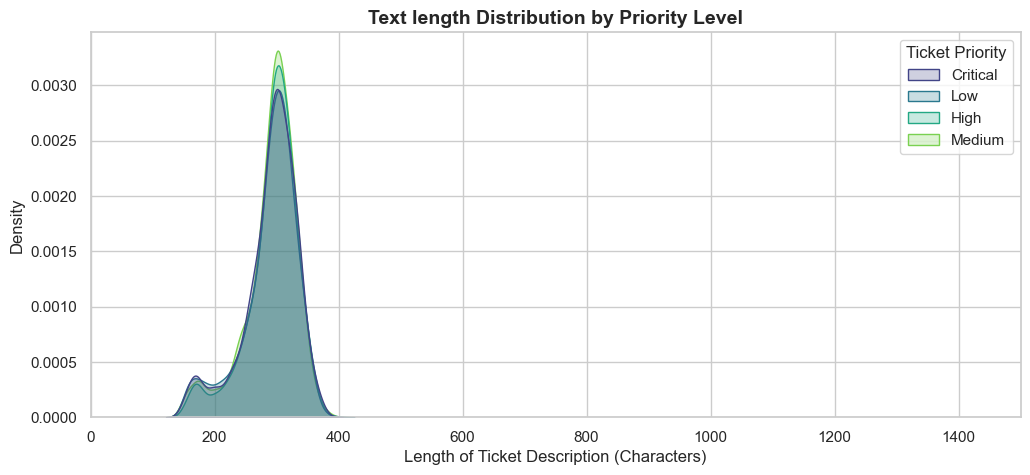

In [27]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='text_len', hue='Ticket Priority', fill=True, palette='viridis')
plt.title('Text length Distribution by Priority Level', fontsize=14, fontweight='bold')
plt.xlabel('Length of Ticket Description (Characters)')
plt.xlim(0, 1500) # Most descriptions fall in this range
plt.show()

C:\Users\SRINATH\AppData\Local\Temp\ipykernel_31240\661651814.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Ticket Type', y='Customer Satisfaction Rating', palette='muted')


AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_'

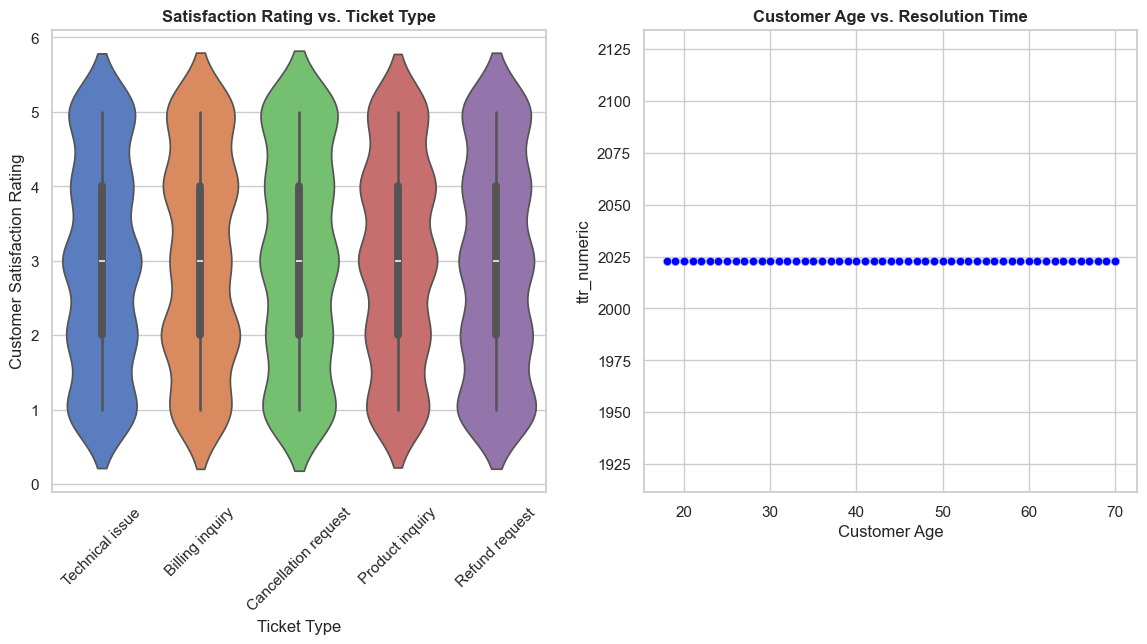

In [28]:
plt.figure(figsize=(14, 6))
# How does Satisfaction Rating relate to Ticket Type?
plt.subplot(1, 2, 1)
sns.violinplot(data=df, x='Ticket Type', y='Customer Satisfaction Rating', palette='muted')
plt.title('Satisfaction Rating vs. Ticket Type', fontweight='bold')
plt.xticks(rotation=45)
# Correlation between Age and TTR (Are older customers' tickets resolved faster?)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Customer Age', y='ttr_numeric', alpha=0.3, color='blue')
plt.title('Customer Age vs. Resolution Time', fontweight='bold')
plt.tight_
layout()
plt.show()

In [29]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'text_len', 'Month_Year',
       'ttr_numeric'],
      dtype='object')

In [30]:
df["Resolution"]

0                                                 NaN
1                                                 NaN
2        Case maybe show recently my computer follow.
3       Try capital clearly never color toward story.
4                         West decision evidence bit.
                            ...                      
8464                                              NaN
8465                                              NaN
8466            Eight account century nature kitchen.
8467                            We seat culture plan.
8468                                              NaN
Name: Resolution, Length: 8469, dtype: object